In [6]:
import matplotlib.pyplot as plt
import pickle
import numpy as np
from pathlib import Path

legend_properties = {'weight': 'bold'}

In [7]:
# Data folder
# Mac path for the Hybrid experiment on decentralization degree.
data_folder = Path(r"/Volumes/T7/data/dao-0310-23/V4_4/Hybrid_mini")

beta_list_file = data_folder / "hybrid_beta_list"
performance_file = data_folder / "hybrid_performance"
diversity_file = data_folder / "hybrid_diversity"
variance_file = data_folder / "hybrid_variance"
cv_file = data_folder / "hybrid_cv"
consensus_performance_file = data_folder / "hybrid_consensus_performance"
entropy_file = data_folder / "hybrid_entropy"
antagonism_file = data_folder / "hybrid_antagonism"
mode_file = data_folder / "hybrid_mode"

with open(beta_list_file, 'rb') as infile:
    beta_list = pickle.load(infile)
with open(performance_file, 'rb') as infile:
    hybrid_performance = pickle.load(infile)
with open(diversity_file, 'rb') as infile:
    hybrid_diversity = pickle.load(infile)
with open(variance_file, 'rb') as infile:
    hybrid_variance = pickle.load(infile)
with open(cv_file, 'rb') as infile:
    hybrid_cv = pickle.load(infile)
with open(consensus_performance_file, 'rb') as infile:
    hybrid_consensus_performance = pickle.load(infile)
with open(entropy_file, 'rb') as infile:
    hybrid_entropy = pickle.load(infile)
with open(antagonism_file, 'rb') as infile:
    hybrid_antagonism = pickle.load(infile)

# mode is diagnostic; it is large and not necessary for core plots.
# Load it only when needed.
try:
    with open(mode_file, 'rb') as infile:
        hybrid_mode = pickle.load(infile)
except FileNotFoundError:
    hybrid_mode = None

# Convert to arrays: shape = [len(beta_list), search_loop]
hybrid_performance = np.array(hybrid_performance)
hybrid_diversity = np.array(hybrid_diversity)
hybrid_variance = np.array(hybrid_variance)
hybrid_cv = np.array(hybrid_cv)
hybrid_consensus_performance = np.array(hybrid_consensus_performance)
hybrid_entropy = np.array(hybrid_entropy)
hybrid_antagonism = np.array(hybrid_antagonism)
beta_array = np.array(beta_list)

print("beta_list:", beta_list)
print("performance shape:", hybrid_performance.shape)
print("consensus performance shape:", hybrid_consensus_performance.shape)
print("entropy shape:", hybrid_entropy.shape)
print("antagonism shape:", hybrid_antagonism.shape)


beta_list: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
performance shape: (11, 300)
consensus performance shape: (11, 300)
entropy shape: (11, 300)
antagonism shape: (11, 300)


In [8]:
# Define more colors
# NUS two colors
nus_blue = "#003D7C"
nus_orange = "#EF7C00"
# Nature three colors
nature_orange = "#F16C23"
nature_blue = "#2B6A99"
nature_green = "#1B7C3D"
# Morandi six colors
morandi_blue = "#046586"
morandi_green =  "#28A9A1"
morandi_yellow = "#C9A77C"
morandi_orange = "#F4A016"
morandi_pink = "#F6BBC6"
morandi_red = "#E71F19"
morandi_purple = "#B08BEB"
# Others
shallow_grey = "#D3D4D3"
deep_grey = "#A6ABB6"

In [9]:
# Helper functions

def set_axis_style(ax):
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["right"].set_linewidth(1.5)
    ax.spines["top"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)


def final_value(matrix):
    """Return final-period value for each beta."""
    return np.array(matrix)[:, -1]


def window_average(matrix, window=50):
    """Return average over the last `window` periods for each beta."""
    matrix = np.array(matrix)
    return np.mean(matrix[:, -window:], axis=1)


def savefig(name):
    plt.savefig(data_folder / name, transparent=True, dpi=300, bbox_inches='tight')

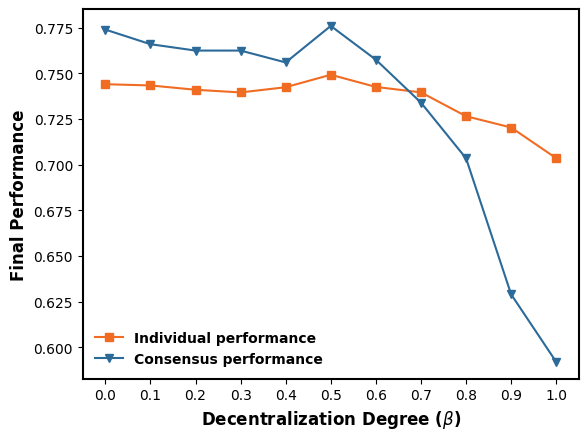

performance list:  [0.74407143 0.74340714 0.74104048 0.73957381 0.74243571 0.7492619
 0.7425881  0.7396119  0.7265619  0.72036905 0.70355476]
consensus performance list:  [0.774  0.766  0.7625 0.7625 0.756  0.776  0.7575 0.734  0.7035 0.629
 0.592 ]


<Figure size 640x480 with 0 Axes>

In [10]:
# Impact of beta on final performance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_performance), "-s", color=nature_orange,
        label="Individual performance")
ax.plot(beta_array, final_value(hybrid_consensus_performance), "-v", color=nature_blue,
        label="Consensus performance")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Performance', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_performance.png")
plt.show()
plt.clf()
print("performance list: ", final_value(hybrid_performance))
print("consensus performance list: ", final_value(hybrid_consensus_performance))


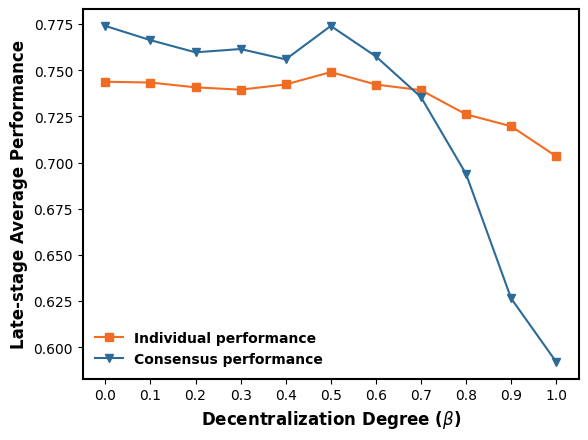

<Figure size 640x480 with 0 Axes>

In [11]:
# Impact of beta on late-stage average performance
# This plot is less sensitive to final-period random fluctuation than the final-value plot.
window = 50
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, window_average(hybrid_performance, window=window), "-s",
        color=nature_orange, label="Individual performance")
ax.plot(beta_array, window_average(hybrid_consensus_performance, window=window), "-v",
        color=nature_blue, label="Consensus performance")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Late-stage Average Performance', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_late_stage_performance.png")
plt.show()
plt.clf()


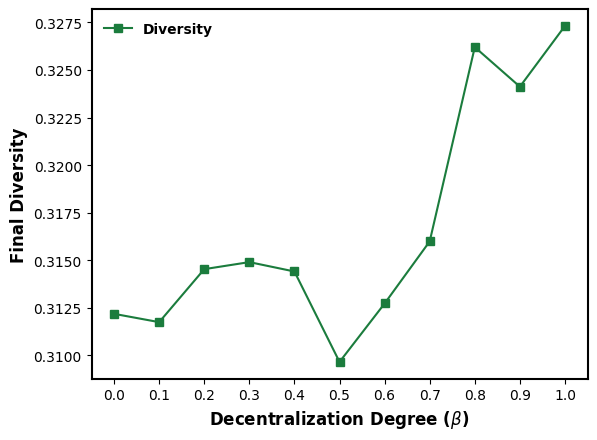

<Figure size 640x480 with 0 Axes>

In [12]:
# Impact of beta on diversity
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_diversity), "-s", color=nature_green,
        label="Diversity")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Diversity', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_diversity.png")
plt.show()
plt.clf()

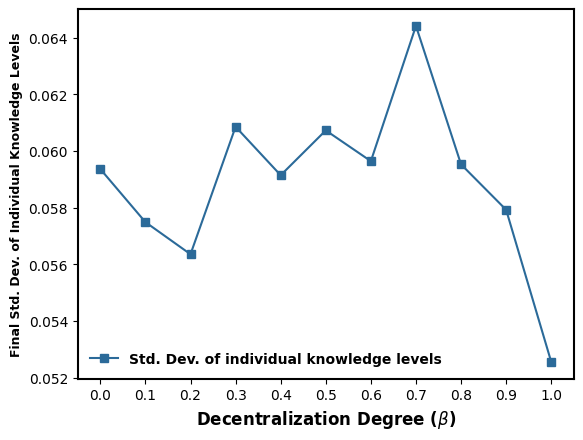

<Figure size 640x480 with 0 Axes>

In [13]:
# Impact of beta on variance
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_variance), "-s", color=nature_blue,
        label="Std. Dev. of individual knowledge levels")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Std. Dev. of Individual Knowledge Levels', fontweight='bold', fontsize=9)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_sd.png")
plt.show()
plt.clf()

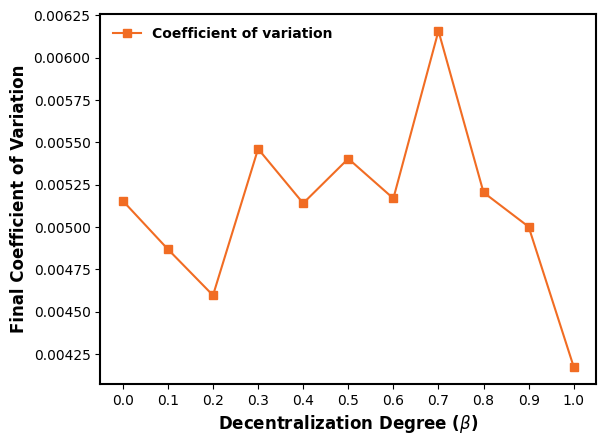

<Figure size 640x480 with 0 Axes>

In [14]:
# Impact of beta on coefficient of variation
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_cv), "-s", color=nature_orange,
        label="Coefficient of variation")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Coefficient of Variation', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_cv.png")
plt.show()
plt.clf()

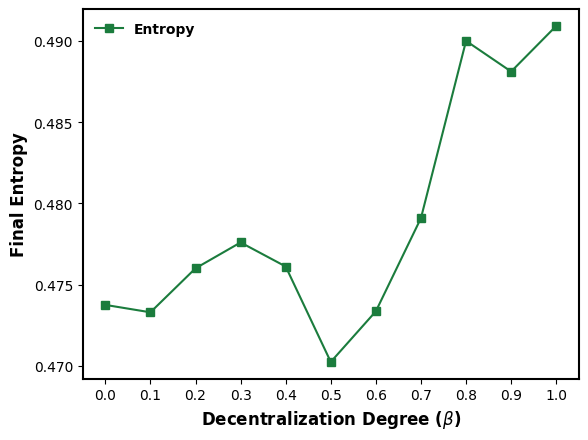

<Figure size 640x480 with 0 Axes>

In [15]:
# Impact of beta on entropy
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_entropy), "-s", color=nature_green,
        label="Entropy")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Entropy', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_entropy.png")
plt.show()
plt.clf()


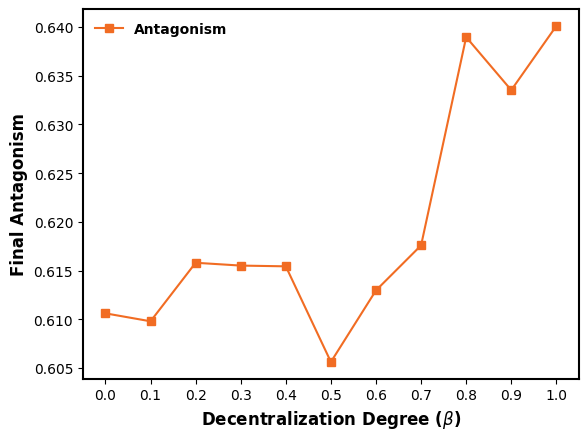

<Figure size 640x480 with 0 Axes>

In [16]:
# Impact of beta on antagonism
fig, ax = plt.subplots()
set_axis_style(ax)

ax.plot(beta_array, final_value(hybrid_antagonism), "-s", color=nature_orange,
        label="Antagonism")

plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
plt.ylabel('Final Antagonism', fontweight='bold', fontsize=12)
plt.xticks(beta_array)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_final_antagonism.png")
plt.show()
plt.clf()


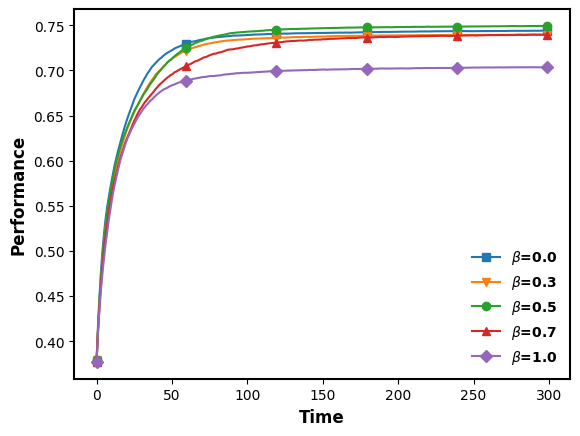

<Figure size 640x480 with 0 Axes>

In [17]:
# Time trajectories by selected beta values
selected_beta_values = [0.0, 0.3, 0.5, 0.7, 1.0]
selected_indices = [int(np.argmin(np.abs(beta_array - beta))) for beta in selected_beta_values]
x = range(hybrid_performance.shape[1])
marker_positions = np.linspace(0, len(x) - 1, num=6, dtype=int)

fig, ax = plt.subplots()
set_axis_style(ax)

markers = ["s", "v", "o", "^", "D"]
for idx, marker in zip(selected_indices, markers):
    ax.plot(x, hybrid_performance[idx], "-" + marker,
            label=rf"$\beta$={beta_array[idx]:.1f}",
            markevery=marker_positions)

plt.xlabel('Time', fontweight='bold', fontsize=12)
plt.ylabel('Performance', fontweight='bold', fontsize=12)
ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
savefig("hybrid_beta_performance_trajectories.png")
plt.show()
plt.clf()

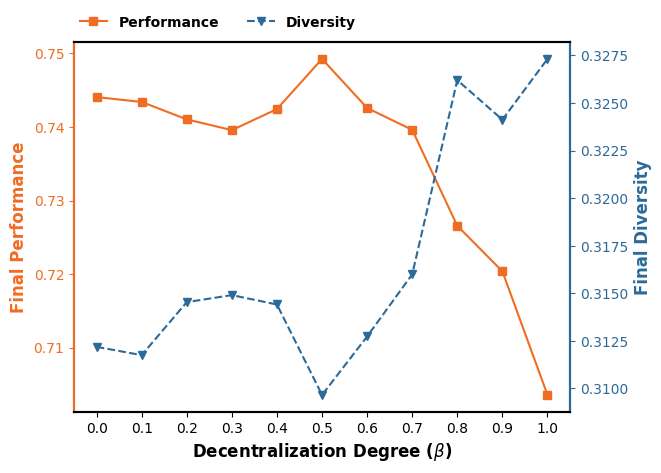

<Figure size 640x480 with 0 Axes>

In [18]:
# Twin plot: final performance and diversity across beta
fig, ax1 = plt.subplots()
ax1.set_xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Final Performance', fontweight='bold', color="black", fontsize=12)

ax2 = ax1.twinx()
ax2.set_ylabel('Final Diversity', fontweight='bold', color="black", fontsize=12)

ax2.spines['left'].set_color(nature_orange)
ax1.yaxis.label.set_color(nature_orange)
ax1.tick_params(axis='y', colors=nature_orange)
ax2.spines['right'].set_color(nature_blue)
ax2.yaxis.label.set_color(nature_blue)
ax2.tick_params(axis='y', colors=nature_blue)

set_axis_style(ax1)
set_axis_style(ax2)

line_1 = ax1.plot(beta_array, final_value(hybrid_performance), "-s",
                  label="Performance", color=nature_orange)
line_2 = ax2.plot(beta_array, final_value(hybrid_diversity), "--v",
                  label="Diversity", color=nature_blue)

plt.xticks(beta_array)
lines = line_1 + line_2
labs = [line.get_label() for line in lines]
ax1.legend(lines, labs, frameon=False, fontsize=12, loc=(0, 1.02),
           ncol=2, prop=legend_properties)

savefig("hybrid_beta_performance_diversity.png")
plt.show()
plt.clf()

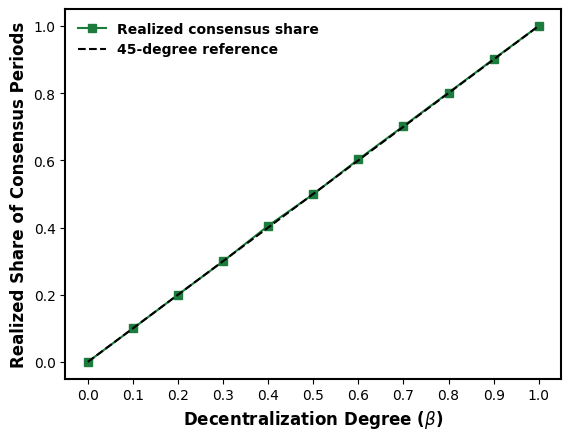

<Figure size 640x480 with 0 Axes>

In [19]:
# Diagnostic: realized share of consensus-channel periods by beta
# This verifies that beta is implemented as the probability of decentralized consensus.
if hybrid_mode is not None:
    consensus_share = []
    for beta_modes in hybrid_mode:
        flat_modes = [mode for run in beta_modes for mode in run]
        consensus_share.append(np.mean([mode == "consensus" for mode in flat_modes]))

    fig, ax = plt.subplots()
    set_axis_style(ax)
    ax.plot(beta_array, consensus_share, "-s", color=nature_green,
            label="Realized consensus share")
    ax.plot(beta_array, beta_array, "k--", label="45-degree reference")

    plt.xlabel(r'Decentralization Degree ($\beta$)', fontweight='bold', fontsize=12)
    plt.ylabel('Realized Share of Consensus Periods', fontweight='bold', fontsize=12)
    plt.xticks(beta_array)
    ax.legend(frameon=False, ncol=1, fontsize=12, prop=legend_properties)
    savefig("hybrid_beta_realized_consensus_share.png")
    plt.show()
    plt.clf()
else:
    print("hybrid_mode file is unavailable; skip mode diagnostic plot.")

In [20]:
# Summary table: final values by beta
summary = {
    "beta": beta_array,
    "final_performance": final_value(hybrid_performance),
    "late_stage_performance": window_average(hybrid_performance, window=50),
    "final_consensus_performance": final_value(hybrid_consensus_performance),
    "final_diversity": final_value(hybrid_diversity),
    "final_variance": final_value(hybrid_variance),
    "final_cv": final_value(hybrid_cv),
    "final_entropy": final_value(hybrid_entropy),
    "final_antagonism": final_value(hybrid_antagonism),
}

for key, value in summary.items():
    print(key, np.round(value, 4))


beta [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
final_performance [0.7441 0.7434 0.741  0.7396 0.7424 0.7493 0.7426 0.7396 0.7266 0.7204
 0.7036]
late_stage_performance [0.7438 0.7433 0.7407 0.7395 0.7423 0.749  0.7423 0.7392 0.7261 0.7197
 0.7034]
final_consensus_performance [0.774  0.766  0.7625 0.7625 0.756  0.776  0.7575 0.734  0.7035 0.629
 0.592 ]
final_diversity [0.3122 0.3118 0.3145 0.3149 0.3144 0.3097 0.3127 0.316  0.3262 0.3241
 0.3273]
final_variance [0.0594 0.0575 0.0564 0.0609 0.0591 0.0607 0.0596 0.0644 0.0595 0.0579
 0.0526]
final_cv [0.0052 0.0049 0.0046 0.0055 0.0051 0.0054 0.0052 0.0062 0.0052 0.005
 0.0042]
final_entropy [0.4738 0.4733 0.476  0.4776 0.4761 0.4702 0.4734 0.4791 0.49   0.4881
 0.4909]
final_antagonism [0.6106 0.6098 0.6158 0.6155 0.6154 0.6056 0.613  0.6176 0.639  0.6335
 0.6401]
